Descargar datos
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9474 - loss: 0.1790 - val_accuracy: 0.9783 - val_loss: 0.0701
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9802 - loss: 0.0632 - val_accuracy: 0.9820 - val_loss: 0.0645
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9863 - loss: 0.0431 - val_accuracy: 0.9892 - val_loss: 0.0458
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

---> F1-Score: 0.9860 <---


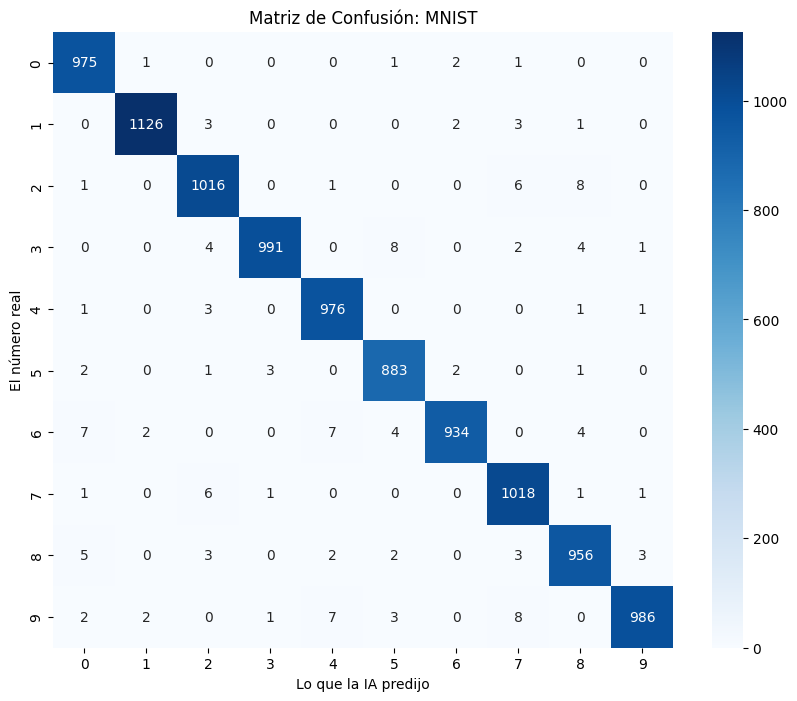

In [1]:
import tensorflow as tf #Libreria IA de Google
from tensorflow.keras import layers, models #Keras es una interfaz mas amigable del anterior
import numpy as np #Librería matemática de python
import matplotlib.pyplot as plt #Gráficas
import seaborn as sns #Trabaja por encima de matplotlib
from sklearn.metrics import confusion_matrix, f1_score #Scikit-Learn para importar fórmulas

print("Descargar datos")
mnist = tf.keras.datasets.mnist #Carga el dataset 
(x_train, y_train) , (x_test, y_test) = mnist.load_data() #La funcion devuelve 60000 imagenes a train y 10000 a test, la x son las imagenes y las y las etiquetas
x_train , x_test = x_train / 255.0 , x_test / 255.0 #Las IAs se atragantan con datos grandes, los rebajamos a un intervalo más pequeño

#Las redes convulocionales CNN esperan imagenes en 3 dimensiones, este dataset solo tiene 2 al ser en blanco y negro.
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

#Creación modelo IA

model = models.Sequential([
    layers.Conv2D(32,(3,3), activation='relu', input_shape=(28, 28, 1)), #Crear capa de convolucion, 32 lupas de 3x3 pixeles, relu hace que las lupas negativas que no coincidan las omita a 0, y el 28 es el tamaño de la imagen que entra
    layers.MaxPool2D((2,2)), #Pilla el máximo de un 2x2 para reducir informacion y no saturar la RAM
    layers.Flatten(), #aplastamiento para pasar las imagenes 2D a una dimension porque la IA solo reconoce de 1
    layers.Dense(64, activation='relu'), #capa de 64 neuronas
    layers.Dense(10, activation='softmax') #capa que da un beredicto del para las 10 categorizaciones distintas de mi modelo

])

#Entremiento

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) #compilar el modelo, adam es el algortimo más usado de optmización, entropia (cuanto te equivocas), cantidad de aciertos
model.fit(x_train, y_train, epochs=3, validation_split=0.1) #entrenar el modelo, repasa las imágenes 3 veces, coge 10% de los datos de entrenamiento para comprobación al final de cada epoch

#Evaluación de resultados

y_pred_prob = model.predict(x_test) #calculo de probabilidad de predicción de los nuevos datos (test)
y_pred = np.argmax(y_pred_prob, axis=1) #predicción máxima (axis es para la busqueda en filas

f1 = f1_score(y_test, y_pred, average='macro')
print(f"\n---> F1-Score: {f1:.4f} <---")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: MNIST')
plt.xlabel('Lo que la IA predijo')
plt.ylabel('El número real')
plt.show()



